# **Regressão: Conceitos Avançados**

## 1 Objetivo

O objetivo desta atividade é aplicar um modelo de regressão polinomial para prever o valor do aluguel dos imóveis, utilizando uma variável diferente da usada durante a aula. Para isso, será utilizada a variável Metragem como variável explicativa e a variável Valor_Aluguel como variável alvo.

Além disso, serão testados modelos polinomiais com graus diferentes, inicialmente com degree=2 e depois com degree=4, com o objetivo de comparar o desempenho entre eles por meio das métricas R² Score e Mean Squared Error. Por fim, também será apresentada uma explicação sobre os conceitos de regularização Ridge, Lasso e Elastic Net.

## 2 Importação das bibliotecas e carregamento da base de dados

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_imoveis = pd.read_csv('ALUGUEL_MOD12.csv', delimiter=';')
df_imoveis

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
...,...,...,...,...,...,...,...
7198,25000,7500,627,4,5,4,6
7199,25000,4600,364,4,2,1,0
7200,25000,3700,266,3,4,3,7
7201,25000,6000,600,4,5,4,8


## 3 Separação de X e Y

In [3]:
# Separando a variável target
y = df_imoveis['Valor_Aluguel']

# Escolhendo uma variável diferente da usada na aula
# Na aula foi utilizado Valor_Condominio, então aqui será usada a variável Metragem
X = df_imoveis[['Metragem']]

In [4]:
X.head()

,Metragem
0,48
1,50
2,40
3,45
4,30


In [5]:
y.head()

0    480
1    500
2    500
3    500
4    500
Name: Valor_Aluguel, dtype: int64

## 4 Processamento dos dados utilizando PolynomialFeatures - Grau 2

In [6]:
# Criando o objeto PolynomialFeatures com grau 2
poly_features = PolynomialFeatures(degree=2)

# Transformando a variável explicativa em termos polinomiais
X_poly = poly_features.fit_transform(X)

X_poly

array([[1.0000e+00, 4.8000e+01, 2.3040e+03],
       [1.0000e+00, 5.0000e+01, 2.5000e+03],
       [1.0000e+00, 4.0000e+01, 1.6000e+03],
       ...,
       [1.0000e+00, 2.6600e+02, 7.0756e+04],
       [1.0000e+00, 6.0000e+02, 3.6000e+05],
       [1.0000e+00, 2.4800e+02, 6.1504e+04]], shape=(7203, 3))

Nesta etapa foi aplicado o PolynomialFeatures com degree=2. 
Essa transformação cria novas variáveis a partir da variável original, incluindo sua potência ao quadrado. 
Como a variável escolhida foi Metragem, o modelo passa a considerar tanto a metragem original quanto a metragem elevada ao quadrado. 
Isso permite que a regressão consiga capturar uma possível relação não linear entre a metragem do imóvel e o valor do aluguel.

## 5 Separação dos dados em treino e teste e treinamento do modelo

In [7]:
# Separando os dados em treino e teste
x_train, x_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=0
)

In [8]:
# Criando e treinando o modelo de regressão linear com os dados transformados
modelo_poly_2 = LinearRegression()
modelo_poly_2.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 6 Previsões para a base de teste e avaliação do modelo

In [9]:
# Realizando as previsões com o modelo polinomial de grau 2
y_pred_poly_2 = modelo_poly_2.predict(x_test)

In [10]:
# Avaliando o modelo
r2_poly_2 = r2_score(y_test, y_pred_poly_2)
mse_poly_2 = mean_squared_error(y_test, y_pred_poly_2)

print('Regressão Polinomial - Grau 2')
print(f'R² Score: {r2_poly_2}')
print(f'Mean Squared Error: {mse_poly_2}')

Regressão Polinomial - Grau 2
R² Score: 0.5423467727683122
Mean Squared Error: 4242097.007687976


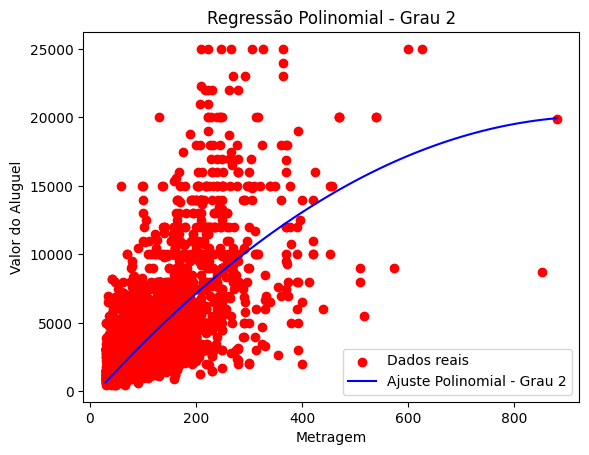

In [11]:
# Criando uma sequência de valores para X para visualização da curva
x_range = pd.DataFrame(
    np.linspace(X['Metragem'].min(), X['Metragem'].max(), 100),
    columns=['Metragem']
)

# Transformando os valores de x_range para o formato polinomial
x_range_poly = poly_features.transform(x_range)

# Fazendo a previsão para a curva
y_range_pred = modelo_poly_2.predict(x_range_poly)

# Plotando os dados reais e a curva da regressão polinomial
plt.scatter(X, y, color='red', label='Dados reais')
plt.plot(x_range, y_range_pred, color='blue', label='Ajuste Polinomial - Grau 2')

plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Polinomial - Grau 2')
plt.legend()
plt.show()

O modelo de regressão polinomial de grau 2 foi treinado utilizando a variável Metragem para prever o Valor_Aluguel. 
O gráfico mostra os dados reais em vermelho e a curva ajustada pelo modelo em azul. 
Como a relação entre metragem e aluguel pode não ser perfeitamente linear, a transformação polinomial permite que o modelo tente capturar melhor essa variação. 
O R² indica quanto da variação do valor do aluguel é explicada pela metragem, enquanto o erro quadrático médio mostra o tamanho médio dos erros do modelo.

## 7 Novo modelo com PolynomialFeatures - Grau 4

In [12]:
# Criando o objeto PolynomialFeatures com grau 4
poly_features_4 = PolynomialFeatures(degree=4)

# Transformando a variável explicativa em termos polinomiais de grau 4
X_poly_4 = poly_features_4.fit_transform(X)

In [13]:
# Separando os dados em treino e teste
x_train_4, x_test_4, y_train_4, y_test_4 = train_test_split(
    X_poly_4, y, test_size=0.2, random_state=0
)

In [14]:
# Criando e treinando o modelo de regressão polinomial de grau 4
modelo_poly_4 = LinearRegression()
modelo_poly_4.fit(x_train_4, y_train_4)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
# Realizando as previsões
y_pred_poly_4 = modelo_poly_4.predict(x_test_4)

In [16]:
# Avaliando o modelo
r2_poly_4 = r2_score(y_test_4, y_pred_poly_4)
mse_poly_4 = mean_squared_error(y_test_4, y_pred_poly_4)

print('Regressão Polinomial - Grau 4')
print(f'R² Score: {r2_poly_4}')
print(f'Mean Squared Error: {mse_poly_4}')

Regressão Polinomial - Grau 4
R² Score: 0.5595780315898855
Mean Squared Error: 4082376.356469475


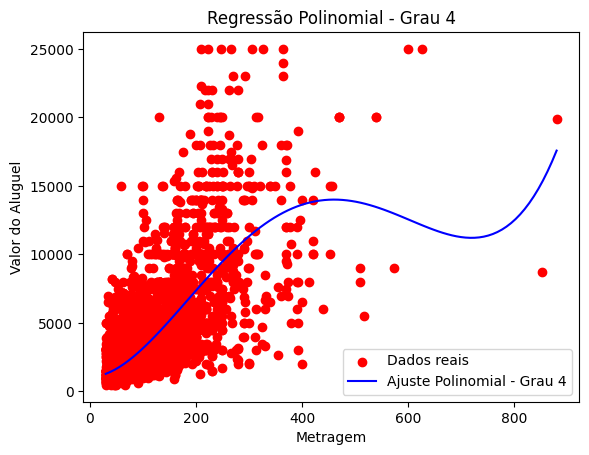

In [17]:
# Criando uma sequência de valores para X para visualização da curva
x_range_4 = pd.DataFrame(
    np.linspace(X['Metragem'].min(), X['Metragem'].max(), 100),
    columns=['Metragem']
)

# Transformando os valores para grau 4
x_range_poly_4 = poly_features_4.transform(x_range_4)

# Fazendo a previsão para a curva
y_range_pred_4 = modelo_poly_4.predict(x_range_poly_4)

# Plotando os dados reais e a curva da regressão polinomial de grau 4
plt.scatter(X, y, color='red', label='Dados reais')
plt.plot(x_range_4, y_range_pred_4, color='blue', label='Ajuste Polinomial - Grau 4')

plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Polinomial - Grau 4')
plt.legend()
plt.show()

Comparando os modelos, o modelo polinomial de grau 4 apresentou desempenho ligeiramente superior ao modelo de grau 2. 
O R² aumentou de aproximadamente 0,5423 para 0,5598, indicando que o modelo de grau 4 explicou uma parcela um pouco maior da variação do Valor_Aluguel. 
Além disso, o Mean Squared Error reduziu de aproximadamente 4.242.097 para 4.082.376, mostrando uma pequena melhora nos erros de previsão. 
Apesar disso, a melhoria não foi muito grande, então o modelo de grau 4 foi superior, mas com ganho moderado em relação ao modelo de grau 2.

## 8 Diferença entre Elastic Net, Ridge e Lasso

Ridge, Lasso e Elastic Net são técnicas de regularização utilizadas em modelos de regressão para reduzir o risco de overfitting. 
A regularização adiciona uma penalização aos coeficientes do modelo, evitando que eles fiquem muito altos e que o modelo se ajuste excessivamente aos dados de treino. 

A regressão Ridge reduz o tamanho dos coeficientes, mas geralmente não zera nenhum deles. 
Ela é útil quando existem variáveis correlacionadas e quando queremos manter todas as variáveis no modelo. 

A regressão Lasso também penaliza os coeficientes, porém pode transformar alguns deles em zero. 
Por isso, além de ajudar a evitar overfitting, o Lasso também pode funcionar como uma seleção automática de variáveis. 

Já o Elastic Net combina as características do Ridge e do Lasso. 
Ele é útil quando temos muitas variáveis ou quando existem variáveis independentes muito correlacionadas entre si, pois consegue reduzir coeficientes e também selecionar variáveis mais relevantes.